In [29]:
%matplotlib inline
from matplotlib import style
style.use('fivethirtyeight')
import matplotlib.pyplot as plt

In [30]:
import numpy as np
import pandas as pd
import datetime as dt

# Reflect Tables into SQLAlchemy ORM

In [31]:
# Python SQL toolkit and Object Relational Mapper
import sqlalchemy
from sqlalchemy.ext.automap import automap_base
from sqlalchemy.orm import Session
from sqlalchemy import create_engine, func

In [32]:
# create engine to hawaii.sqlite
engine = create_engine("sqlite:///Resources/hawaii.sqlite")

In [33]:
# reflect an existing database into a new model
Base = automap_base()

# reflect the tables
Base.prepare(engine, reflect=True)

C:\Users\Owner\AppData\Local\Temp\ipykernel_9424\930725367.py:5: SADeprecationWarning: The AutomapBase.prepare.reflect parameter is deprecated and will be removed in a future release.  Reflection is enabled when AutomapBase.prepare.autoload_with is passed.
  Base.prepare(engine, reflect=True)


In [34]:
# View all of the classes that automap found
Base.classes.keys()


['measurement', 'station']

In [35]:
# Save references to each table
Mesurement = Base.classes.measurement
Station = Base.classes.station

In [36]:
# Create our session (link) from Python to the DB
session = Session(engine)

# Exploratory Precipitation Analysis

In [37]:
# Find the most recent date in the data set.
recent_date = session.query(Mesurement.date).order_by(Mesurement.date.desc()).first()
recent_date

('2017-08-23',)

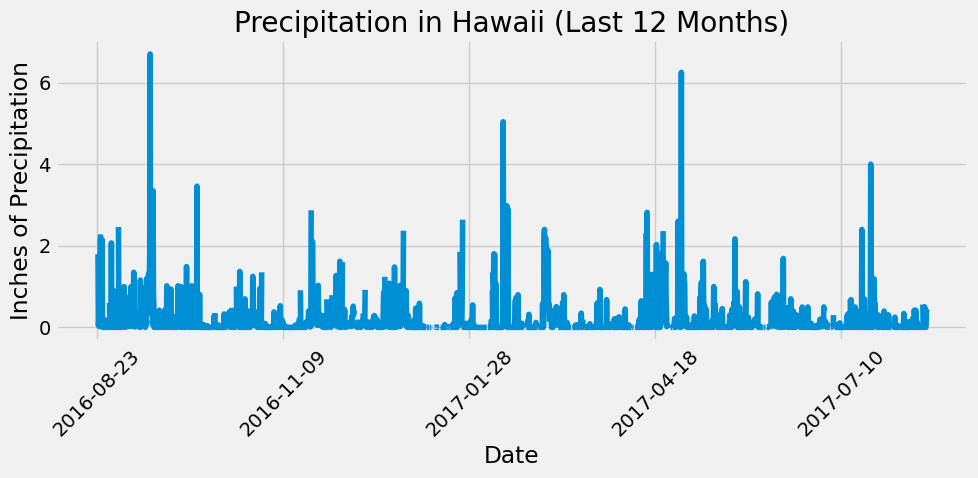

In [38]:
# Design a query to retrieve the last 12 months of precipitation data and plot the results. 
# Starting from the most recent data point in the database. 
recent_date = dt.datetime.strptime(recent_date[0], "%Y-%m-%d").date()

# Calculate the date one year from the last date in data set.
last_year = recent_date - dt.timedelta(days=365)

# Perform a query to retrieve the data and precipitation scores
precipitation_scores = session.query(Mesurement.date, Mesurement.prcp).\
    filter(Mesurement.date >= last_year).all()

# Save the query results as a Pandas DataFrame. Explicitly set the column names
df_precipitation = pd.DataFrame(precipitation_scores, columns=['date', 'precipitation'])

# Sort the dataframe by date
df_precipitation.set_index('date', inplace=True)
df_precipitation = df_precipitation.sort_index()

# Use Pandas Plotting with Matplotlib to plot the data
df_precipitation.plot(title='Precipitation in Hawaii (Last 12 Months)', figsize=(10, 5), legend=False)
plt.xlabel('Date')
plt.ylabel('Inches of Precipitation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [39]:
# Use Pandas to calculate the summary statistics for the precipitation data
df_precipitation.describe()


,precipitation
count,2021.000000
mean,0.177279
std,0.461190
min,0.000000
25%,0.000000
50%,0.020000
75%,0.130000
max,6.700000


# Exploratory Station Analysis

In [40]:
# Design a query to calculate the total number of stations in the dataset
station_count = session.query(Station).count()
station_count

9

In [41]:
# Design a query to find the most active stations (i.e. which stations have the most rows?)
# List the stations and their counts in descending order.
active_stations = session.query(Mesurement.station, func.count(Mesurement.station)).\
    group_by(Mesurement.station).\
    order_by(func.count(Mesurement.station).desc()).all()
active_stations


[('USC00519281', 2772),
 ('USC00519397', 2724),
 ('USC00513117', 2709),
 ('USC00519523', 2669),
 ('USC00516128', 2612),
 ('USC00514830', 2202),
 ('USC00511918', 1979),
 ('USC00517948', 1372),
 ('USC00518838', 511)]

In [42]:
# Using the most active station id from the previous query, calculate the lowest, highest, and average temperature.
temp_station = active_stations[0][0]
temp_stats = session.query(func.min(Mesurement.tobs), func.max(Mesurement.tobs), func.avg(Mesurement.tobs)).\
    filter(Mesurement.station == temp_station).all()
temp_stats


[(54.0, 85.0, 71.66378066378067)]

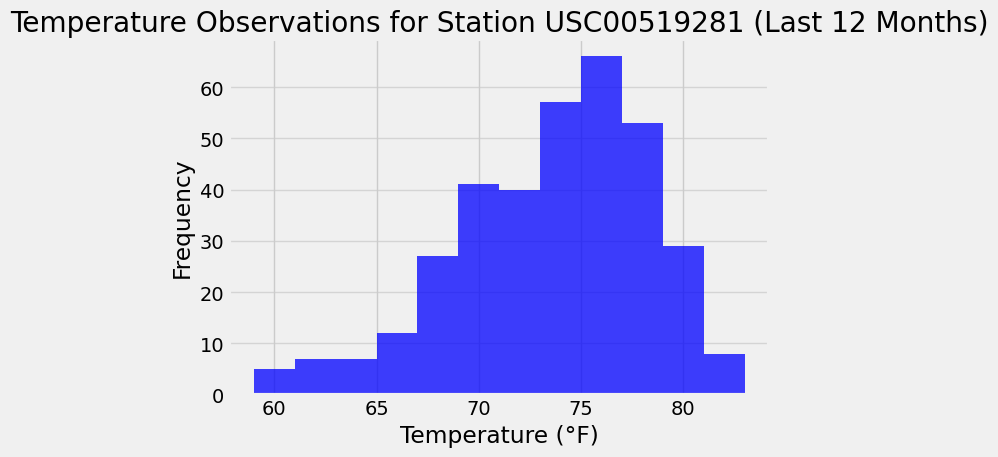

In [43]:
# Using the most active station id
# Query the last 12 months of temperature observation data for this station and plot the results as a histogram
temp_data = session.query(Mesurement.tobs).\
    filter(Mesurement.station == temp_station).\
    filter(Mesurement.date >= last_year).all()
temp_data = [temp[0] for temp in temp_data]

# plot the results as a histogram
plt.hist(temp_data, bins=12, alpha=0.75, color='blue')
plt.title(f'Temperature Observations for Station {temp_station} (Last 12 Months)')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


# Close Session

In [44]:
# Close Session
session.close()